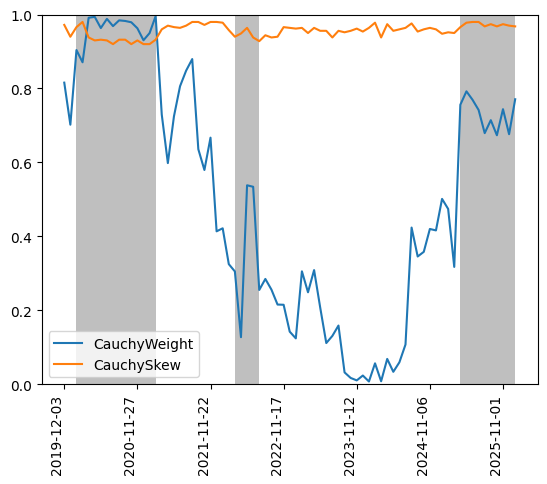

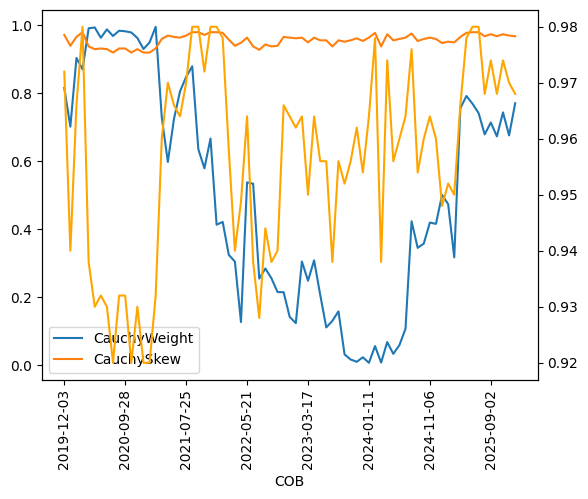

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

dfs = []



for i in range(11):
    skew = str(90 + i)
    df = pd.read_csv(f'C:\\dev\\MLCopula\\data\\weights\\OptimalCopulaGCS{skew}.csv')
    #df = df.drop(['CauchySkew'], axis=1)
    df = df.rename(columns={'CauchyWeight': 'CauchyWeight' + skew, 
                            'Error': 'Error' + skew, 
                            'CauchySkew': 'CauchySkew' + skew })
    df = df.set_index('COB')
    dfs.append(df)

res = pd.concat(dfs, axis=1)

def process(row):
    weights = [row['Error' + str(90 + i)] for i in range(11)]
    weights_min = min(weights)
    weights = [w - weights_min for w in weights]
    sum_weights = sum(weights)
    weights = [w/sum_weights for w in weights]

    cw = sum([row['CauchyWeight' + str(90 + i)]*weights[i] for i in range(11)])
    cs = sum([row['CauchySkew' + str(90 + i)]*weights[i] for i in range(11)])

    return (cw,cs)


def process2(row):
    weights = np.array([row['Error' + str(90 + i)] for i in range(11)])
    i_min= np.argmin(weights)

    cw_list = [row['CauchyWeight' + str(90 + i)] for i in range(11)]
    cs_list = [row['CauchySkew' + str(90 + i)] for i in range(11)]

    cw = cw_list[i_min]
    cs = cs_list[i_min]
    w = weights[i_min]

    return (cw,cs)


def process3(row, nmin=5):
    weightsall = [row['Error' + str(90 + i)] for i in range(11)]
    smallestval = []
    smallest = []
    for _ in range(nmin):
        smallestval.append(min(weightsall))
        weightsall.remove(min(weightsall))

    weightsall = [row['Error' + str(90 + i)] for i in range(11)]
    for i in range(11):
        if weightsall[i] in smallestval:
            smallest.append(i)

    weights = [row['Error' + str(90 + i)] for i in smallest]
    weights_min = min(weights)
    weights = [w - weights_min for w in weights]
    sum_weights = sum(weights)
    weights = [w/sum_weights for w in weights]

    cw = sum([row['CauchyWeight' + str(90 + i)] for i in smallest])/len(smallest)
    cs = sum([row['CauchySkew' + str(90 + i)] for i in smallest])/len(smallest)

    return (cw,cs)

res['Temp'] = res.apply(lambda row: process3(row) , axis=1)
res['CauchyWeight'] = res.apply(lambda row: row['Temp'][0], axis=1)
res['CauchySkew'] = res.apply(lambda row: row['Temp'][1], axis=1)
#res['Error'] = res.apply(lambda row: row['Temp'][2], axis=1)

res = res[['CauchyWeight', 'CauchySkew']]


plt.ylim(0.0, 1.0)
plt.plot(res.index, res)
plt.xticks(ticks=range(0, len(res.index), 12), labels=res.index[::12])
plt.xticks(rotation=90, ha='right')
plt.legend(res.columns)
#plt.axvspan("2008-09-01", "2009-06-28", facecolor='grey', alpha=0.5) # finicial crash
plt.axvspan("2020-02-01", "2021-02-25", facecolor='grey', alpha=0.5) # covid 
plt.axvspan("2022-03-22", "2022-07-20", facecolor='grey', alpha=0.5) # war in ukraine and commodity crisis
plt.axvspan("2025-04-05", "2025-12-31", facecolor='grey', alpha=0.5) # Trump tariffs
plt.show()

res.plot(rot=90)
plt.twinx()
plt.plot(res['CauchySkew'], color= 'orange')

plt.show()

C:\Users\sarkh\AppData\Local\Temp\ipykernel_29552\1102881092.py:62: RuntimeWarning: invalid value encountered in scalar divide
  weights = [w/sum_weights for w in weights]


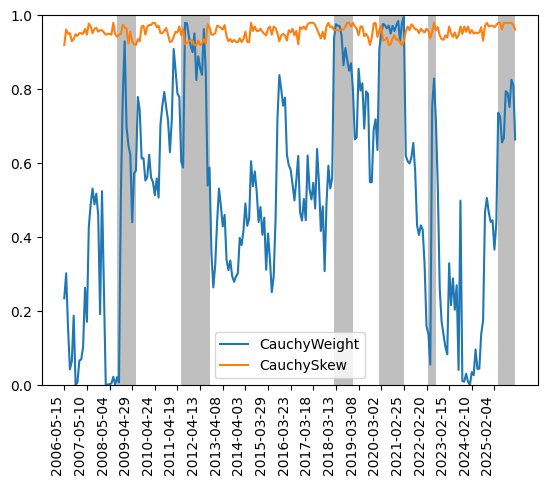

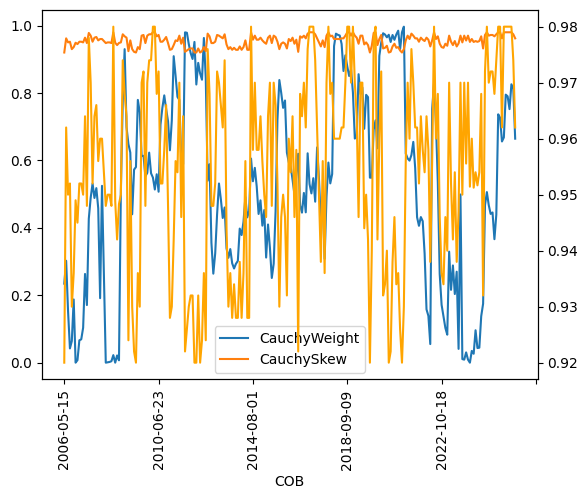

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

dfs = []
for i in range(11):
    skew = str(90 + i)
    df = pd.read_csv(f'C:\\dev\\MLCopula\\data\\weights\\OptimalCopulaGCS{skew}gbt20y.csv')
    #df = df.drop(['CauchySkew'], axis=1)
    df = df.rename(columns={'CauchyWeight': 'CauchyWeight' + skew, 
                            'Error': 'Error' + skew, 
                            'CauchySkew': 'CauchySkew' + skew })
    df = df.set_index('COB')
    dfs.append(df)

res = pd.concat(dfs, axis=1)

def process(row):
    weights = [row['Error' + str(90 + i)] for i in range(11)]
    weights_min = min(weights)
    weights = [w - weights_min for w in weights]
    sum_weights = sum(weights)
    weights = [w/sum_weights for w in weights]

    cw = sum([row['CauchyWeight' + str(90 + i)]*weights[i] for i in range(11)])
    cs = sum([row['CauchySkew' + str(90 + i)]*weights[i] for i in range(11)])

    return (cw,cs)


def process2(row):
    weights = np.array([row['Error' + str(90 + i)] for i in range(11)])
    i_min= np.argmin(weights)

    cw_list = [row['CauchyWeight' + str(90 + i)] for i in range(11)]
    cs_list = [row['CauchySkew' + str(90 + i)] for i in range(11)]

    cw = cw_list[i_min]
    cs = cs_list[i_min]
    w = weights[i_min]

    return (cw,cs)


def process3(row, nmin=5):
    weightsall = [row['Error' + str(90 + i)] for i in range(11)]
    smallestval = []
    smallest = []
    for _ in range(nmin):
        smallestval.append(min(weightsall))
        weightsall.remove(min(weightsall))

    weightsall = [row['Error' + str(90 + i)] for i in range(11)]
    for i in range(11):
        if weightsall[i] in smallestval:
            smallest.append(i)

    weights = [row['Error' + str(90 + i)] for i in smallest]
    weights_min = min(weights)
    weights = [w - weights_min for w in weights]
    sum_weights = sum(weights)
    weights = [w/sum_weights for w in weights]

    cw = sum([row['CauchyWeight' + str(90 + i)] for i in smallest])/len(smallest)
    cs = sum([row['CauchySkew' + str(90 + i)] for i in smallest])/len(smallest)

    return (cw,cs)

res['Temp'] = res.apply(lambda row: process3(row) , axis=1)
res['CauchyWeight'] = res.apply(lambda row: row['Temp'][0], axis=1)
res['CauchySkew'] = res.apply(lambda row: row['Temp'][1], axis=1)
#res['Error'] = res.apply(lambda row: row['Temp'][2], axis=1)

res = res[['CauchyWeight', 'CauchySkew']]

plt.ylim(0.0, 1.0)
plt.plot(res.index, res)
plt.xticks(ticks=range(0, len(res.index), 12), labels=res.index[::12])
plt.xticks(rotation=90, ha='right')
plt.legend(res.columns)
plt.axvspan("2008-09-01", "2009-06-28", facecolor='grey', alpha=0.5) # finicial crash
plt.axvspan("2011-06-18", "2012-09-10", facecolor='grey', alpha=0.5) # euro debt crisis
plt.axvspan("2018-02-11", "2018-12-08", facecolor='grey', alpha=0.5) # 2018 volmagedon + us china trade war + christmas crash
plt.axvspan("2020-02-01", "2021-02-25", facecolor='grey', alpha=0.5) # covid 
plt.axvspan("2022-03-22", "2022-07-20", facecolor='grey', alpha=0.5) # war in ukraine and commodity crisis
plt.axvspan("2025-04-05", "2025-12-31", facecolor='grey', alpha=0.5) # Trump tariffs
plt.show()

res.plot(rot=90)
plt.twinx()
plt.plot(res['CauchySkew'], color= 'orange')

plt.show()



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

dfs = []
for i in range(11):
    skew = str(90 + i)
    df = pd.read_csv(f'C:\\dev\\MLCopula\\data\\weights\\OptimalCopulaGCS{skew}rt20y.csv')
    #df = df.drop(['CauchySkew'], axis=1)
    df = df.rename(columns={'CauchyWeight': 'CauchyWeight' + skew, 
                            'Error': 'Error' + skew, 
                            'CauchySkew': 'CauchySkew' + skew })
    df = df.set_index('COB')
    dfs.append(df)

res = pd.concat(dfs, axis=1)

def process(row):
    weights = [row['Error' + str(90 + i)] for i in range(11)]
    weights_min = min(weights)
    weights = [w - weights_min for w in weights]
    sum_weights = sum(weights)
    weights = [w/sum_weights for w in weights]

    cw = sum([row['CauchyWeight' + str(90 + i)]*weights[i] for i in range(11)])
    cs = sum([row['CauchySkew' + str(90 + i)]*weights[i] for i in range(11)])

    return (cw,cs)


def process2(row):
    weights = np.array([row['Error' + str(90 + i)] for i in range(11)])
    i_min= np.argmin(weights)

    cw_list = [row['CauchyWeight' + str(90 + i)] for i in range(11)]
    cs_list = [row['CauchySkew' + str(90 + i)] for i in range(11)]

    cw = cw_list[i_min]
    cs = cs_list[i_min]
    w = weights[i_min]

    return (cw,cs)


def process3(row, nmin=5):
    weightsall = [row['Error' + str(90 + i)] for i in range(11)]
    smallestval = []
    smallest = []
    for _ in range(nmin):
        smallestval.append(min(weightsall))
        weightsall.remove(min(weightsall))

    weightsall = [row['Error' + str(90 + i)] for i in range(11)]
    for i in range(11):
        if weightsall[i] in smallestval:
            smallest.append(i)

    weights = [row['Error' + str(90 + i)] for i in smallest]
    weights_min = min(weights)
    weights = [w - weights_min for w in weights]
    sum_weights = sum(weights)
    weights = [w/sum_weights for w in weights]

    cw = sum([row['CauchyWeight' + str(90 + i)] for i in smallest])/len(smallest)
    cs = sum([row['CauchySkew' + str(90 + i)] for i in smallest])/len(smallest)

    return (cw,cs)

res['Temp'] = res.apply(lambda row: process3(row) , axis=1)
res['CauchyWeight'] = res.apply(lambda row: row['Temp'][0], axis=1)
res['CauchySkew'] = res.apply(lambda row: row['Temp'][1], axis=1)
#res['Error'] = res.apply(lambda row: row['Temp'][2], axis=1)

res = res[['CauchyWeight', 'CauchySkew']]

plt.ylim(0.0, 1.0)
plt.plot(res.index, res)
plt.xticks(ticks=range(0, len(res.index), 12), labels=res.index[::12])
plt.xticks(rotation=90, ha='right')
plt.legend(res.columns)
plt.axvspan("2008-09-01", "2009-06-28", facecolor='grey', alpha=0.5) # finicial crash
plt.axvspan("2011-06-18", "2012-09-10", facecolor='grey', alpha=0.5) # euro debt crisis
plt.axvspan("2018-02-11", "2018-12-08", facecolor='grey', alpha=0.5) # 2018 volmagedon + us china trade war + christmas crash
plt.axvspan("2020-02-01", "2021-02-25", facecolor='grey', alpha=0.5) # covid 
plt.axvspan("2022-03-22", "2022-07-20", facecolor='grey', alpha=0.5) # war in ukraine and commodity crisis
plt.axvspan("2025-04-05", "2025-12-31", facecolor='grey', alpha=0.5) # Trump tariffs
plt.show()

res.plot(rot=90)
plt.twinx()
plt.plot(res['CauchySkew'], color= 'orange')

plt.show()



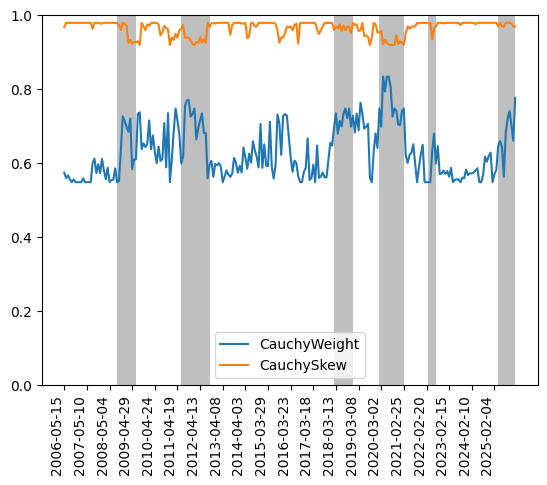

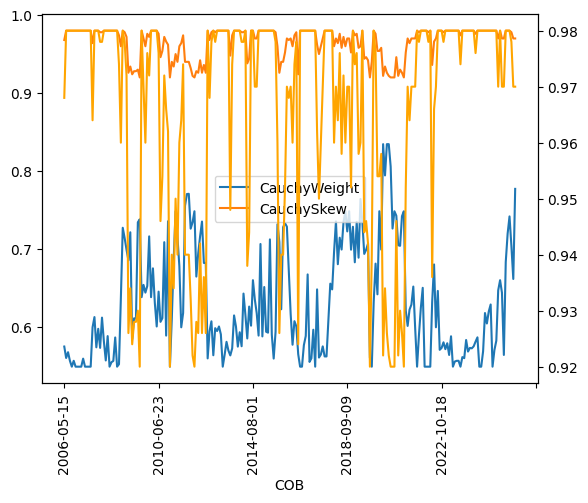

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

dfs = []
for i in range(11):
    skew = str(90 + i)
    df = pd.read_csv(f'C:\\dev\\MLCopula\\data\\weights\\OptimalCopulaGCS{skew}rt20y.csv')
    #df = df.drop(['CauchySkew'], axis=1)
    df = df.rename(columns={'CauchyWeight': 'CauchyWeight' + skew, 
                            'Error': 'Error' + skew, 
                            'CauchySkew': 'CauchySkew' + skew })
    df = df.set_index('COB')
    dfs.append(df)

res = pd.concat(dfs, axis=1)

def process(row):
    weights = [row['Error' + str(90 + i)] for i in range(11)]
    weights_min = min(weights)
    weights = [w - weights_min for w in weights]
    sum_weights = sum(weights)
    weights = [w/sum_weights for w in weights]

    cw = sum([row['CauchyWeight' + str(90 + i)]*weights[i] for i in range(11)])
    cs = sum([row['CauchySkew' + str(90 + i)]*weights[i] for i in range(11)])

    return (cw,cs)


def process2(row):
    weights = np.array([row['Error' + str(90 + i)] for i in range(11)])
    i_min= np.argmin(weights)

    cw_list = [row['CauchyWeight' + str(90 + i)] for i in range(11)]
    cs_list = [row['CauchySkew' + str(90 + i)] for i in range(11)]

    cw = cw_list[i_min]
    cs = cs_list[i_min]
    w = weights[i_min]

    return (cw,cs)


def process3(row, nmin=5):
    weightsall = [row['Error' + str(90 + i)] for i in range(11)]
    smallestval = []
    smallest = []
    for _ in range(nmin):
        smallestval.append(min(weightsall))
        weightsall.remove(min(weightsall))

    weightsall = [row['Error' + str(90 + i)] for i in range(11)]
    for i in range(11):
        if weightsall[i] in smallestval:
            smallest.append(i)

    weights = [row['Error' + str(90 + i)] for i in smallest]
    weights_min = min(weights)
    weights = [w - weights_min for w in weights]
    sum_weights = sum(weights)
    weights = [w/sum_weights for w in weights]

    cw = sum([row['CauchyWeight' + str(90 + i)] for i in smallest])/len(smallest)
    cs = sum([row['CauchySkew' + str(90 + i)] for i in smallest])/len(smallest)

    return (cw,cs)

res['Temp'] = res.apply(lambda row: process3(row) , axis=1)
res['CauchyWeight'] = res.apply(lambda row: row['Temp'][0], axis=1)
res['CauchySkew'] = res.apply(lambda row: row['Temp'][1], axis=1)
#res['Error'] = res.apply(lambda row: row['Temp'][2], axis=1)

res = res[['CauchyWeight', 'CauchySkew']]

plt.ylim(0.0, 1.0)
plt.plot(res.index, res)
plt.xticks(ticks=range(0, len(res.index), 12), labels=res.index[::12])
plt.xticks(rotation=90, ha='right')
plt.legend(res.columns)
plt.axvspan("2008-09-01", "2009-06-28", facecolor='grey', alpha=0.5) # finicial crash
plt.axvspan("2011-06-18", "2012-09-10", facecolor='grey', alpha=0.5) # euro debt crisis
plt.axvspan("2018-02-11", "2018-12-08", facecolor='grey', alpha=0.5) # 2018 volmagedon + us china trade war + christmas crash
plt.axvspan("2020-02-01", "2021-02-25", facecolor='grey', alpha=0.5) # covid 
plt.axvspan("2022-03-22", "2022-07-20", facecolor='grey', alpha=0.5) # war in ukraine and commodity crisis
plt.axvspan("2025-04-05", "2025-12-31", facecolor='grey', alpha=0.5) # Trump tariffs
plt.show()

res.plot(rot=90)
plt.twinx()
plt.plot(res['CauchySkew'], color= 'orange')

plt.show()



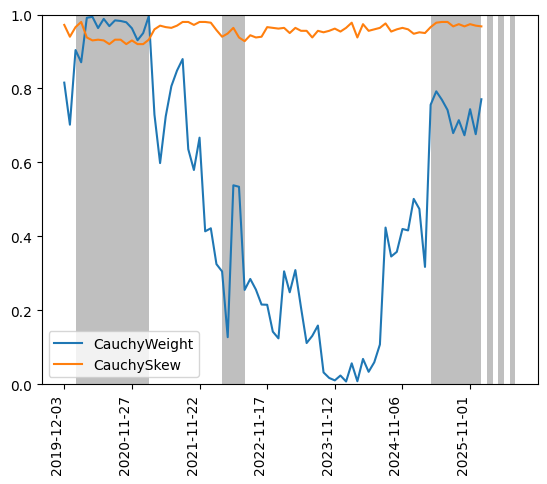

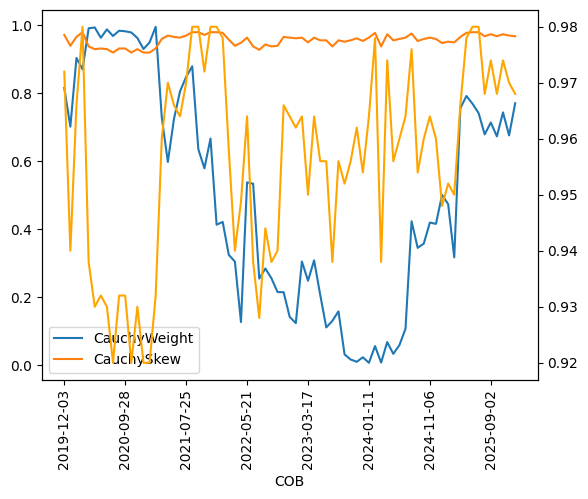

C:\Users\sarkh\AppData\Local\Temp\ipykernel_20340\1564488461.py:58: RuntimeWarning: invalid value encountered in scalar divide
  weights = [w/sum_weights for w in weights]


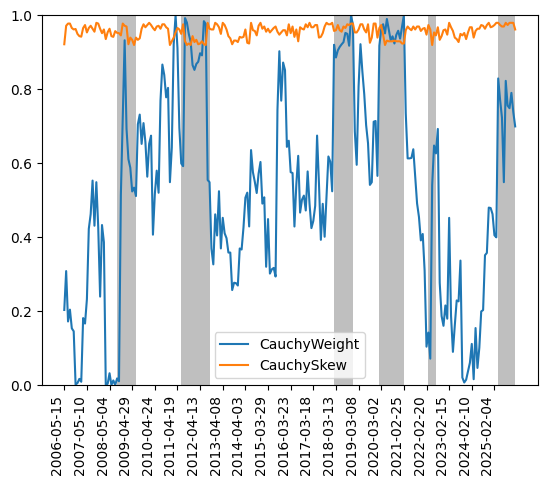

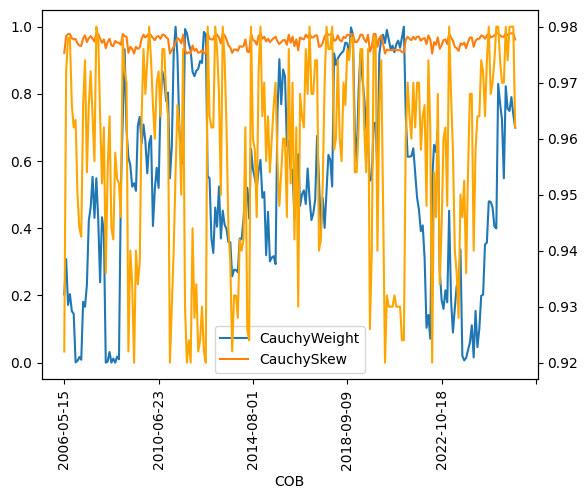

C:\Users\sarkh\AppData\Local\Temp\ipykernel_20340\1564488461.py:58: RuntimeWarning: invalid value encountered in scalar divide
  weights = [w/sum_weights for w in weights]


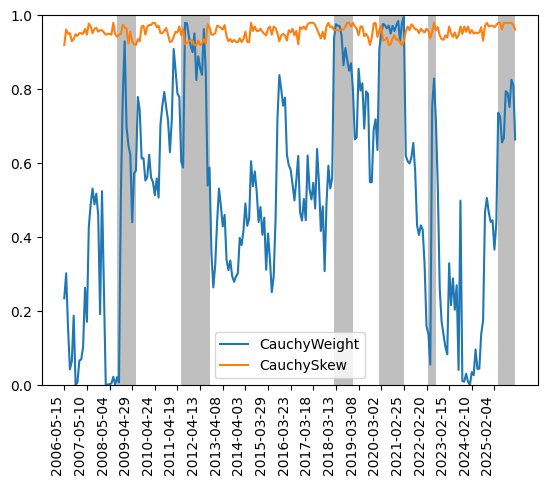

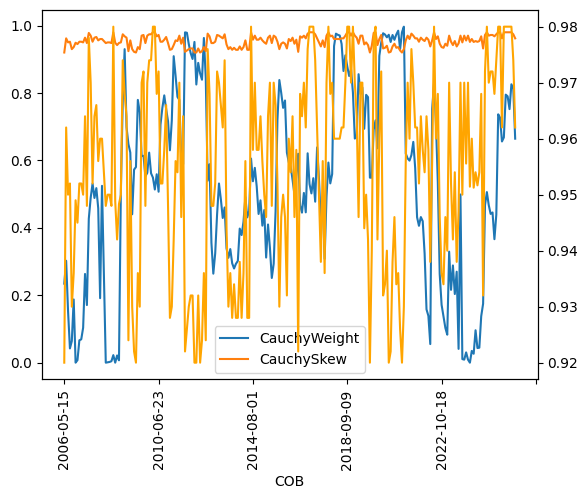

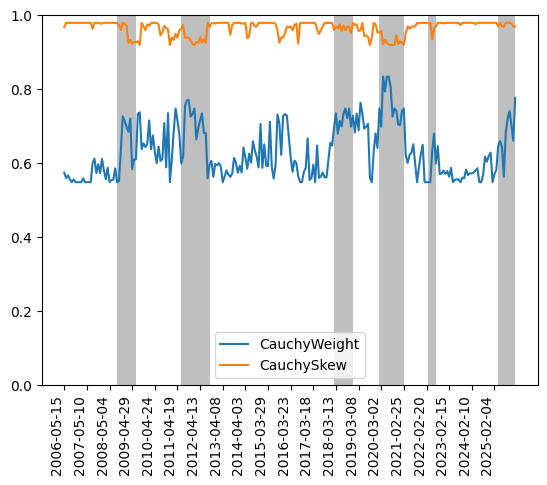

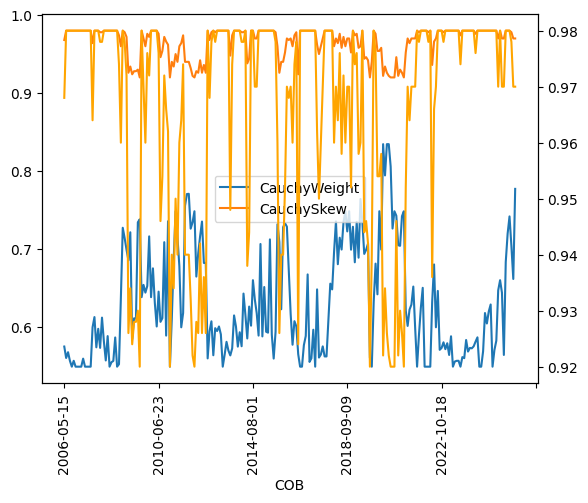

C:\Users\sarkh\AppData\Local\Temp\ipykernel_20340\1564488461.py:58: RuntimeWarning: invalid value encountered in scalar divide
  weights = [w/sum_weights for w in weights]


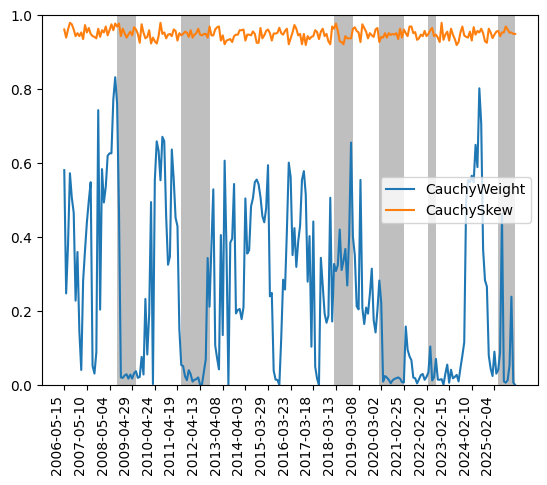

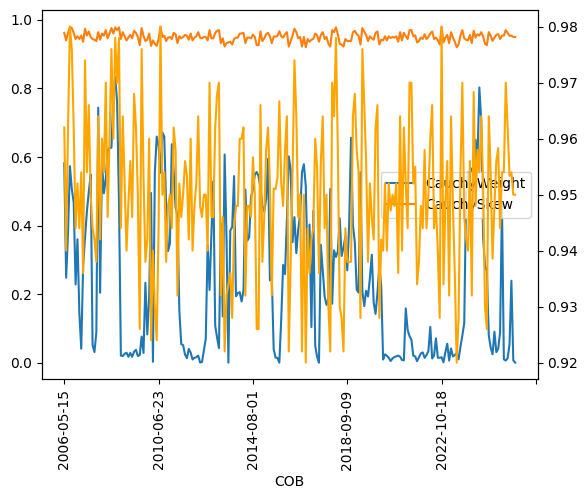

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


cases = [
    "", #gp
    "_20y", #gp
    "gbt20y",
    "rt20y",
    "gp20y-hgt"
]

def process(row):
    weights = [row['Error' + str(90 + i)] for i in range(11)]
    weights_min = min(weights)
    weights = [w - weights_min for w in weights]
    sum_weights = sum(weights)
    weights = [w/sum_weights for w in weights]

    cw = sum([row['CauchyWeight' + str(90 + i)]*weights[i] for i in range(11)])
    cs = sum([row['CauchySkew' + str(90 + i)]*weights[i] for i in range(11)])

    return (cw,cs)


def process2(row):
    weights = np.array([row['Error' + str(90 + i)] for i in range(11)])
    i_min= np.argmin(weights)

    cw_list = [row['CauchyWeight' + str(90 + i)] for i in range(11)]
    cs_list = [row['CauchySkew' + str(90 + i)] for i in range(11)]

    cw = cw_list[i_min]
    cs = cs_list[i_min]
    w = weights[i_min]

    return (cw,cs)


def process3(row, nmin=5):
    weightsall = [row['Error' + str(90 + i)] for i in range(11)]
    smallestval = []
    smallest = []
    for _ in range(nmin):
        smallestval.append(min(weightsall))
        weightsall.remove(min(weightsall))

    weightsall = [row['Error' + str(90 + i)] for i in range(11)]
    for i in range(11):
        if weightsall[i] in smallestval:
            smallest.append(i)

    weights = [row['Error' + str(90 + i)] for i in smallest]
    weights_min = min(weights)
    weights = [w - weights_min for w in weights]
    sum_weights = sum(weights)
    weights = [w/sum_weights for w in weights]

    cw = sum([row['CauchyWeight' + str(90 + i)] for i in smallest])/len(smallest)
    cs = sum([row['CauchySkew' + str(90 + i)] for i in smallest])/len(smallest)

    return (cw,cs)


for case in cases: 
    dfs = []
    for i in range(11):
        skew = str(90 + i)
        df = pd.read_csv(f'C:\\dev\\MLCopula\\data\\weights\\OptimalCopulaGCS{skew}{case}.csv')
        df = df.rename(columns={'CauchyWeight': 'CauchyWeight' + skew, 
                                'Error': 'Error' + skew, 
                                'CauchySkew': 'CauchySkew' + skew })
        df = df.set_index('COB')
        dfs.append(df)

    res = pd.concat(dfs, axis=1)

    res['Temp'] = res.apply(lambda row: process3(row) , axis=1)
    res['CauchyWeight'] = res.apply(lambda row: row['Temp'][0], axis=1)
    res['CauchySkew'] = res.apply(lambda row: row['Temp'][1], axis=1)
    #res['Error'] = res.apply(lambda row: row['Temp'][2], axis=1)

    res = res[['CauchyWeight', 'CauchySkew']]

    plt.ylim(0.0, 1.0)
    plt.plot(res.index, res)
    plt.xticks(ticks=range(0, len(res.index), 12), labels=res.index[::12])
    plt.xticks(rotation=90, ha='right')
    plt.legend(res.columns)
    plt.axvspan("2008-09-01", "2009-06-28", facecolor='grey', alpha=0.5) # finicial crash
    plt.axvspan("2011-06-18", "2012-09-10", facecolor='grey', alpha=0.5) # euro debt crisis
    plt.axvspan("2018-02-11", "2018-12-08", facecolor='grey', alpha=0.5) # 2018 volmagedon + us china trade war + christmas crash
    plt.axvspan("2020-02-01", "2021-02-25", facecolor='grey', alpha=0.5) # covid 
    plt.axvspan("2022-03-22", "2022-07-20", facecolor='grey', alpha=0.5) # war in ukraine and commodity crisis
    plt.axvspan("2025-04-05", "2025-12-31", facecolor='grey', alpha=0.5) # Trump tariffs
    plt.show()

    res.plot(rot=90)
    plt.twinx()
    plt.plot(res['CauchySkew'], color= 'orange')

    plt.show()

